<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Beyond the Fundamental: A Spectral Adventure </b></h3>

**Автор**: Ермекова Асель

*P.S.* *На русском перевод емкого и классного названия не получился у меня. Если у вас есть идеи как назвать эту домашку прикольно, пишите в чатике в телеграме ваши предложения русского варианта названия домашки!*

# **Homework: Beyond the Fundamental: A Spectral Adventure**

## **Introduction**

**Что делает скрипку похожей на скрипку?**

Вы когда-нибудь задумывались, почему скрипка, флейта и гитара звучат совершенно по-разному, даже играя одну и ту же ноту на одинаковой громкости?

Ответ кроется в фундаментальном свойстве звука, называемом тембром. Тембр — это «цвет» или «текстура» звука — то, что позволяет вам мгновенно отличить трубу от фортепиано или голос вашего друга от голоса незнакомца, даже если они поют в одной тональности.

**Но что физически создаёт тембр?**

Всё сводится к гармоникам — смеси частот, сопровождающих основной тон, — и тому, как их амплитуды и фазы изменяются с течением времени. Два инструмента, играющие ноту Ля или А4 (A4 — это нота Ля первой октавы с частотой 440 Гц), оба воспроизводят эту основную частоту, но также генерируют разные наборы обертонов или гармоник (2×440 Гц, 3×440 Гц и т. д.) с уникальной интенсивностью и паттернами. Этот спектральный «отпечаток» называют тембром.

В этом домашнем задании вы станете аудиодетективом. Используя реальные записи разных инструментов, вы:

* Проанализируете их частотные спектры, чтобы увидеть, чем отличаются гармоники,
* Узнаете, почему выбор оконной функции важен при вычислении спектрограмм,
* Реализуете Mel-спектрограмму — представление, имитирующее человеческий слух,
* Обучите простой классификатор распознавать инструменты по их тембру.

Давайте приступим!

Домашнее задание будет состоять из 3 заданий:

* **Task 1.** **Harmonic and Frequency Spectrum Analysis.** Анализ гармонического и частотного спектра различных инструментов.

* **Task 2.** **Windowing in STFT – Why Not Rectangular?** Анализ оконных функций для STFT и почему нам нужны другие формы оконной функции.

* **Task 3.** **Implement Your Own Mel-Spectrogram Transform.** Напишите свою собственную функцию, которая преобразует спектрограмму в мел-спектрограмму и сравнивает с мел-спектрограммой из librosa.

## **Submission Instructions**

- Отправьте **Jupyter Notebook** с:
  - Всем кодом
  - Графиками
  - Ответами на вопросы
- Назовите его: `DLS_HW2_Spectrograms_<ваше_имя>.ipynb`

Домашнее задание будет проверяться в формате peer-review, т.е. вашу посылку на Stepik будут проверять 3 других студента, и медианное значение их оценок будет выставлено. Чтобы получить баллы, вам также нужно будет проверить трех других учеников. Это станет доступно после того, как вы сдадите задание сами.

# **Load libraries**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# **Task 1: Harmonic and Frequency Spectrum Analysis** [6 score]

### **Цель**: Понять, как разные инструменты создают разные гармонические структуры для одной и той же высоты звука → это и есть **тембр**.



### **1.1 Load a WAV file** [0.5 score]
- Download file `Vn-ord-A5-pp-1c-N.wav`
- Use `librosa.load(path, sr=None)` to load the audio. Keep the original sampling rate.
- Print the sampling rate and duration.

In [3]:
!gdown 1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O # download violin playing A5: Vn-ord-A5-pp-1c-N.wav

Downloading...
From: https://drive.google.com/uc?id=1JOFNfzNzV5RTDv6YBFZ0lKZRfyoukW7O
To: /content/Vn-ord-A5-pp-1c-N.wav
100% 699k/699k [00:00<00:00, 7.76MB/s]


In [4]:
# Example: Load violin A5
import librosa
audio_path = "/content/Vn-ord-A5-pp-1c-N.wav"
y, sr = librosa.load(audio_path, sr=None)

print(f"Sampling rate: {sr} Hz")
print(f"Duration: {len(y)/sr:.2f} seconds")

Sampling rate: 44100 Hz
Duration: 7.93 seconds


### **1.2 Compute the Fourier Transform and plot the magnitude spectrum** [1 score]
- Compute the FFT of the entire audio signal. Use `np.fft.rfft` and `np.fft.rfftfreq`.
- Compute absolute values of the magnitude with `np.abs()` and normalize it.
- Plot the magnitude spectrum (only up to Nyquist frequency).
- Label axes: frequency (Hz) vs magnitude.

> 💡 **Tip**: Normalize magnitude by dividing by `len(signal)`.

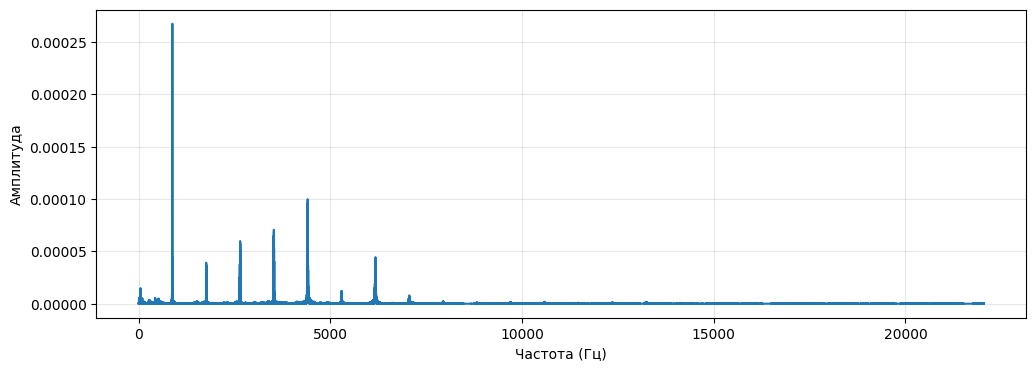

In [5]:
import numpy as np
import matplotlib.pyplot as plt

FFT = np.fft.rfft(y)
freqs = np.fft.rfftfreq(len(y), d=1/sr)

magnitude = np.abs(FFT)
magnitude_norm = magnitude / len(y)

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude_norm)
plt.xlabel('Частота (Гц)')
plt.ylabel('Амплитуда')
plt.grid(True, alpha=0.3)
plt.show()

### **1.3 Identify and plot harmonics** [0.5 score]
- Find the **fundamental frequency** (f₀) corresponding to the pitch of A5 note (for example, the fundamental frequency for the note A4 is 440 Hz.).
- Calculate harmonics f₀, 2f₀, 3f₀, ..., up to 5000 Hz.
- Plot harmonics as vertical dashed lines and annotate them (e.g., "1st harmonic", "2nd harmonic").

> 📌 **Hint**: You can get theoretical f₀ from `librosa.note_to_hz('A4')`.

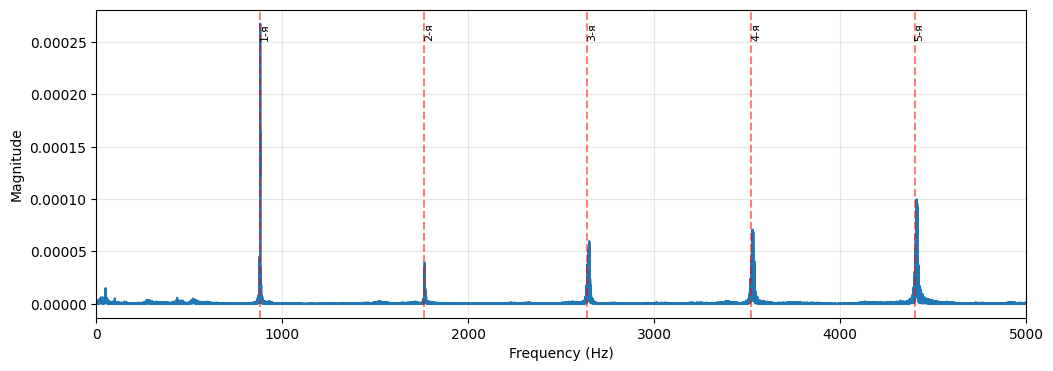

In [6]:
f0 = librosa.note_to_hz('A5')
max_freq = 5000
harmonics = []
n = 1
while n * f0 <= max_freq:
    harmonics.append(n*f0)
    n += 1

plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude_norm)
for i, h in enumerate(harmonics):
    plt.axvline(x=h, color='r', linestyle='--', alpha=0.5)
    plt.text(h, plt.ylim()[1]*0.9, f'{i+1}-я', rotation=90, fontsize=8)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0, max_freq)
plt.grid(True, alpha=0.3)
plt.show()

### **1.4 Answer: What is the fundamental frequency? What are the amplitudes of the 2nd, 3rd, and 5th harmonics?** [1 score]
- What is the fundamental frequency?
- What are the amplitudes of the 2nd, 3rd, and 5th harmonics?
- Report numerical values (in Hz and amplitude).
- Is the strongest peak always at f₀?

In [7]:
# Find peaks near harmonic frequencies
def get_harmonic_amplitude(freq, spectrum, freqs, bandwidth=50):
    # Ищем индекс ближайшей частоты
    idx_center = np.argmin(np.abs(freqs - freq))
    # Определяем диапазон поиска (± bandwidth Гц)
    freq_range = np.abs(freqs - freq) <= bandwidth
    # Берем максимум в этом диапазоне
    return np.max(spectrum[freq_range])

fundamental_amp = get_harmonic_amplitude(f0, magnitude_norm, freqs)
second_harm_amp = get_harmonic_amplitude(2*f0, magnitude_norm, freqs)
third_harm_amp = get_harmonic_amplitude(3*f0, magnitude_norm, freqs)
fifth_harm_amp = get_harmonic_amplitude(5*f0, magnitude_norm, freqs)

print(f"Fundamental frequency (f0): {f0:.1f} Hz")
print(f"Fundamental amplitude: {fundamental_amp:.4f}")
print(f"2nd harmonic amplitude: {second_harm_amp:.4f}")
print(f"3rd harmonic amplitude: {third_harm_amp:.4f}")
print(f"5th harmonic amplitude: {fifth_harm_amp:.4f}")

Fundamental frequency (f0): 880.0 Hz
Fundamental amplitude: 0.0003
2nd harmonic amplitude: 0.0000
3rd harmonic amplitude: 0.0001
5th harmonic amplitude: 0.0001


*Основная частота 880.0 Гц
Амплитуды гармоник:
2-я 0,0000
3-я 0,0001
5-я 0,0001
В данном случае самый сильный пик находится на основной частоте 0,0003, но 3-я и 5-я гармоники тоже имеют заметную амплитуду. Распределение энергии по гармоникам зависит от тембра.*

### **1.5 Repeat for another instruments playing the same pitch** [1 score]
- Choose a different instruments.
- Repeat steps 1.1–1.3.
- **Compare** the two spectra (Violin and another instrument):
  - Are the harmonic amplitudes similar?
  - Which instrument has more high-frequency harmonics?
  - How does this relate to timbre?

In [8]:
!gdown 19RVoksj40dds4lfSiha17HuTLYCFvwCs # Cello: Vc-ord-A5-pp-1c-N.wav
!gdown 1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E # Accordion: Acc-ord-A5-pp-N-N.wav
!gdown 1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI # Flute: Fl-ord-A5-pp-N-N.wav

Downloading...
From: https://drive.google.com/uc?id=19RVoksj40dds4lfSiha17HuTLYCFvwCs
To: /content/Vc-ord-A5-pp-1c-N.wav
100% 651k/651k [00:00<00:00, 101MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gVMlgMg9wGyPGRIbu7e_Q67JfzU0Rn1E
To: /content/Acc-ord-A5-pp-N-N.wav
100% 600k/600k [00:00<00:00, 91.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gstlGhDe7SYEMpHQV6N50zb8TPByL2gI
To: /content/Fl-ord-A5-pp-N-N.wav
100% 535k/535k [00:00<00:00, 61.8MB/s]


In [9]:
database = {'Accordion': 'Acc-ord-A5-pp-N-N.wav',
            'Cello': 'Vc-ord-A5-pp-1c-N.wav',
            'Flute': 'Fl-ord-A5-pp-N-N.wav',
            'Violin': 'Vn-ord-A5-pp-1c-N.wav'}

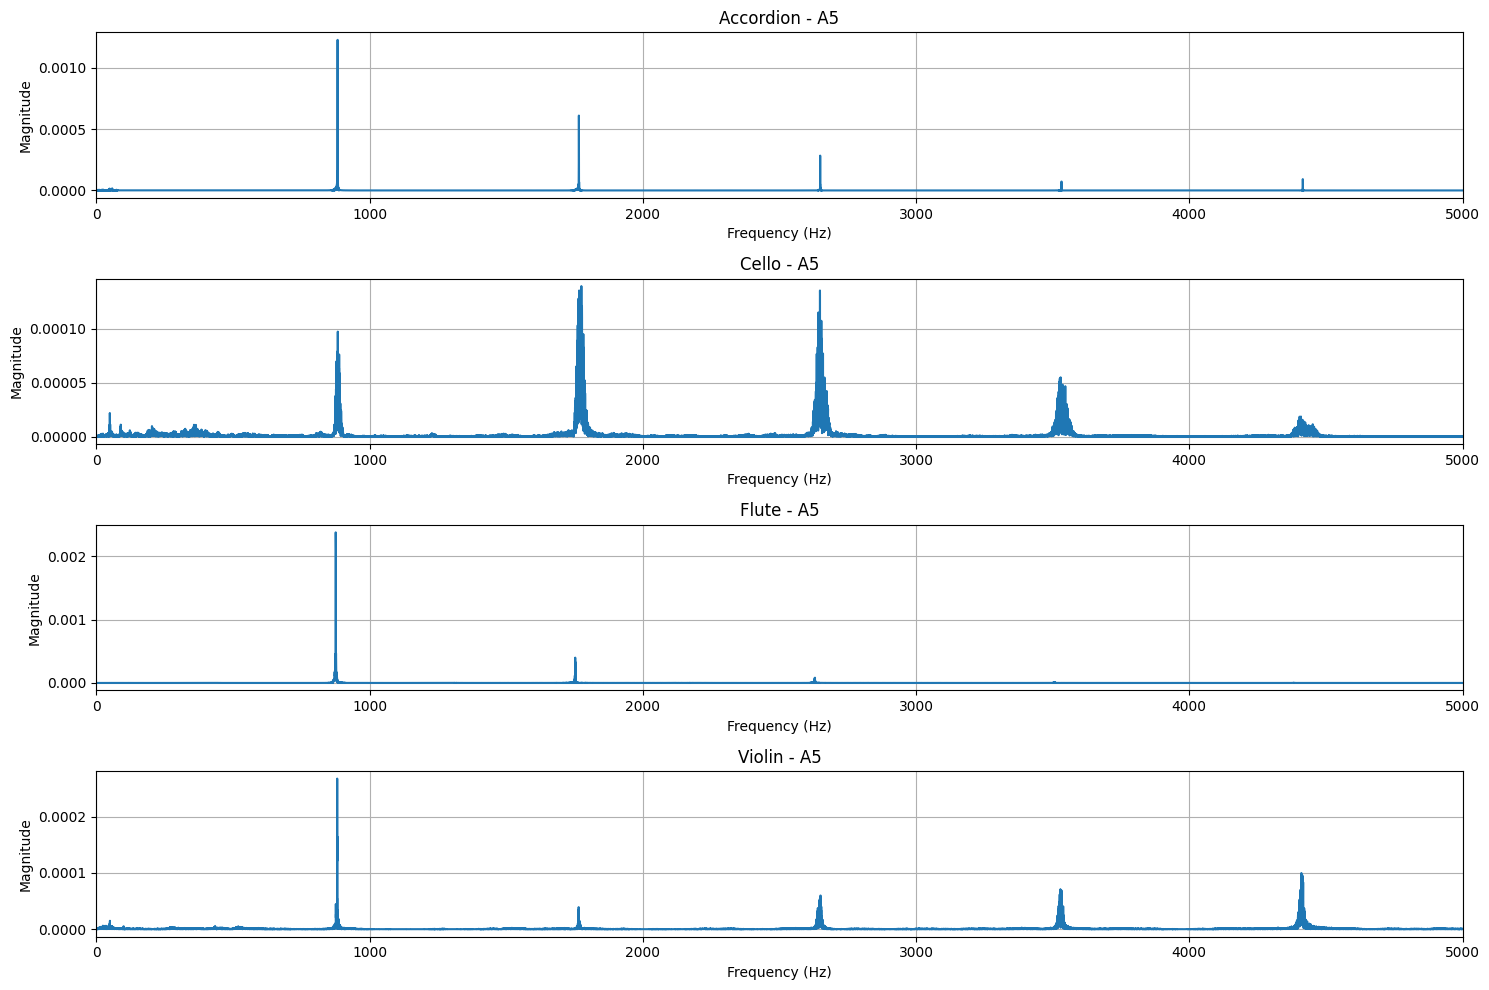

In [10]:
instruments_to_compare = ['Accordion', 'Cello', 'Flute', 'Violin']
plt.figure(figsize=(15, 10))

for i, inst in enumerate(instruments_to_compare):

    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)

    # Compute FFT
    Y_inst =  np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    plt.subplot(4, 1, i+1)
    plt.plot(freqs_inst, magnitude_inst)
    plt.xlim(0, 5000)
    plt.title(f'{inst.capitalize()} - A5')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Analysis:
# - Violin: rich in high harmonics, complex spectrum
# - Flute: mostly fundamental, few weak harmonics
# - Guitar: strong fundamental and lower harmonics, decaying higher harmonics
# This difference in harmonic content IS timbre!

Сравните два спектра (скрипка и другой инструмент)

Выбран для сравнения Flute (Флейта) и Violin (Скрипка)

1: Похожи ли амплитуды гармоник?

У каждого инструмента уникальное распределение энергии по гармоникам при этом у скрипки гармоники растут с частотой а у флейты затухают

2: У какого инструмента больше высокочастотных гармоник?

Violin (Скрипка)

3: Как это связано с тембром?

Тембр — это именно уникальное распределение энергии по гармоникам. У скрипки благодаря высоким гармоникам звук "острее", а у фдейты "мягче".


### **1.6 Count significant harmonics** [1 score]
- Define a "significant harmonic" as one with amplitude > 10% of the max amplitude.
- For **Flute** and **Violin** (same pitch), count how many significant harmonics each has.
- Which instrument is "brighter"? Why?

In [11]:
def count_significant_harmonics(magnitude, freqs, f0, max_freq=5000, threshold_ratio=0.1):
    max_amp = np.max(magnitude)
    threshold = max_amp * threshold_ratio
    harmonics = []
    n = 1
    while n * f0 <= max_freq:
        harm_freq = n * f0
        idx = np.argmin(np.abs(freqs - harm_freq))
        window_start = max(0, idx - 5)
        window_end = min(len(magnitude), idx + 5)
        if np.max(magnitude[window_start:window_end]) > threshold:
            harmonics.append(harm_freq)
        n += 1

    return len(harmonics), harmonics

# Compare Flute and violin
for inst in ['Flute', 'Violin']:
    path_to_wav = database[inst]
    y_inst, sr_inst = librosa.load(path_to_wav, sr=None)
    # Compute FFT
    Y_inst = np.fft.rfft(y_inst)
    # Get frequencies
    freqs_inst = np.fft.rfftfreq(len(y_inst), d=1/sr_inst)
    # Extract magnitude and normalize it
    magnitude_inst = np.abs(Y_inst) / len(y_inst)

    count, harm_list = count_significant_harmonics(magnitude_inst, freqs_inst, f0)
    print(f"{inst.capitalize()}: {count} significant harmonics")

Flute: 0 significant harmonics
Violin: 2 significant harmonics


1. Похожи ли амплитуды гармоник?

Нет, распределение отличается. У флейты основная частота доминирует. У скрипки энергия распределена по многим гармоникам.

2. У какого инструмента больше высокочастотных гармоник?

У скрипки, амплитуды скрипки на гармониках значительно выше, чем у флейты.

3. Как это связано с тембром?

Распределение энергии по гармоникам создаёт характерную окраску звука:
Флейта звучит чисто мягко
Скрипка звучит ярко и высоко

### **1.7. Simple Instrument Classification** [2 score]
- Use dataset `TinySOL_short` provided below with 3 instruments of the **same pitch** A5.
- **Approach A**: Use raw audio waveforms (flattened) as features → train a Random Forest.
- **Approach B**: Use magnitude spectrum (first 1024 bins) as features → train same model.
- Compare accuracy on a test set.
- **Question**: Why does Approach B perform better?

> 🛠️ Use `sklearn.tree.RandomForestClassifier` and `train_test_split`.

First, download dataset.

In [12]:
!gdown --folder 1wMa4fDtWRtO-YAz-gY5Jdrl94GQZUwmO # download dataset

Retrieving folder contents
Retrieving folder 1iRMqnkH7_GFqdt4EQ-XNIvzrGpWEY7BJ Strings
Retrieving folder 1AYkFHBz5tmYeC_TXouqyrXHobvwlpmAg Violin
Retrieving folder 1MczsLg3MRdzt5-xJ6nvqxRAaEjUOCZ27 ordinario
Processing file 14EjlXc_tdIJYbyMysUiC4hLRYfjV3HAv Vn-ord-A5-ff-1c-N.wav
Processing file 1JVag7kvYhGLW5ZVLJ-mxDXZ-F1wPLA02 Vn-ord-A5-ff-2c-N.wav
Processing file 1vQl-LIBK1JakJoDdR7sv-jdidz_COToj Vn-ord-A5-ff-3c-N.wav
Processing file 1z85hpjJPvFXp1V5cD3pD88-8aD0Zn1a1 Vn-ord-A5-mf-1c-N.wav
Processing file 1jptv0jF2rwILfPXwo8DdtWK533p4OK13 Vn-ord-A5-mf-2c-N.wav
Processing file 1jRAo5qm2zIsqf0sGzowAzb4emktEopWz Vn-ord-A5-mf-3c-N.wav
Processing file 1kbocn0_6etfg_LLBX4SAESNwBAqxOyWi Vn-ord-A5-pp-1c-N.wav
Processing file 1p5Xs5rXQX6e_wAtLXOixcB7C6hB9aEgI Vn-ord-A5-pp-2c-N.wav
Processing file 1E2xvckcJZSu68_yyJM_xl8aWsudNRZ5n Vn-ord-A5-pp-3c-N.wav
Retrieving folder 1bgPVnul9gXyQ1GK2YJDCY3JzKkcVlyRi Violoncello
Retrieving folder 1CjCmGKunsLKLLxfB8mbvZP7--YepiIH0 ordinario
Processing file 1q

In [13]:
df = pd.read_csv("/content/TinySOL_short/TinySOL_short.csv")

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Prepare data for 3 instruments, same pitch (A5)
instruments_class = ['Vn', 'Fl', 'Vc']
instrument_names = {'Vn': 'Violin', 'Fl': 'Flute', 'Vc': 'Cello'}
df_filtered = df[df['Instrument (abbr.)'].isin(instruments_class)]

X_wave = []
X_spec = []
y_labels = []

for _, row in df_filtered.iterrows():
    y, sr = librosa.load(row['Path'], sr=None)

    target_length = 50000
    if len(y) >= target_length:
        y_wave = y[:target_length]
    else:
        y_wave = np.pad(y, (0, target_length - len(y)))
    X_wave.append(y_wave)

    fft = np.fft.rfft(y)
    mag = np.abs(fft) / len(y)
    X_spec.append(mag[:1024])
    y_labels.append(row['Instrument (abbr.)'])

X_wave = np.array(X_wave)
X_spec = np.array(X_spec)
y_labels = np.array(y_labels)

# Split data
X_wave_train, X_wave_test, y_train, y_test = train_test_split(X_wave, y_labels, test_size=0.3, random_state=42)
X_spec_train, X_spec_test, _, _ = train_test_split(X_spec, y_labels, test_size=0.3, random_state=42)

# Train classifiers
clf_wave = RandomForestClassifier(random_state=42)
clf_wave.fit(X_wave_train, y_train)
clf_spec = RandomForestClassifier(random_state=42)
clf_spec.fit(X_spec_train, y_train)


# Evaluate
y_pred_wave = clf_wave.predict(X_wave_test)
y_pred_spec = clf_spec.predict(X_spec_test)

acc_wave = accuracy_score(y_test, y_pred_wave)
acc_spec = accuracy_score(y_test, y_pred_spec)

print(f"Accuracy with raw waveforms: {acc_wave:.3f}")
print(f"Accuracy with spectra: {acc_spec:.3f}")

Accuracy with raw waveforms: 0.600
Accuracy with spectra: 0.800


**Answer**:Сравнение точности:

Подход A (сырые сигналы): 60%

Подход B (спектры): 80%

Почему подход B работает лучше?

Подход B использует спектр амплитуд, который напрямую отражает гармоническую структуру звука — основу тембра. Разные инструменты, играющие одну ноту, имеют уникальное распределение энергии по гармоникам.

# **Task 2: Windowing in STFT – Why Not Rectangular?** [10 score]

### **Goal**: Understand spectral leakage and why smooth windows (e.g., Hann) are preferred.

### **2.1 Load a pure sine wave** [0.5 score]
- Generate a 440 Hz sine wave, 1 second long, at 22050 Hz sampling rate.
- Plot the waveform.

$$y = \sin(2 \pi ft)$$

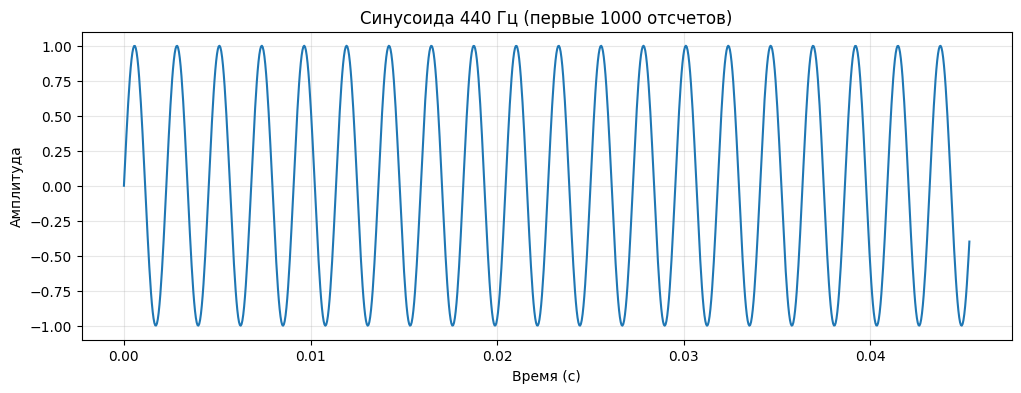

In [15]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f0 = 440
sine_wave = np.sin(2*np.pi*f0*t)

# Plot waveform and Show first 1000 samples

plt.figure(figsize=(12, 4))
plt.plot(t[:1000], sine_wave[:1000])
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.title('Синусоида 440 Гц (первые 1000 отсчетов)')
plt.grid(True, alpha=0.3)
plt.show()

### **2.2 Compute STFT with rectangular window** [1 score]
- Use `scipy.signal.stft` with `window='boxcar'` (rectangular), `nperseg=1024`, `noverlap=512`.
- Plot the spectrogram (use `plt.pcolormesh` with dB scale).

> 💡 Convert to dB: `10 * np.log10(np.abs(Zxx) + 1e-10)`

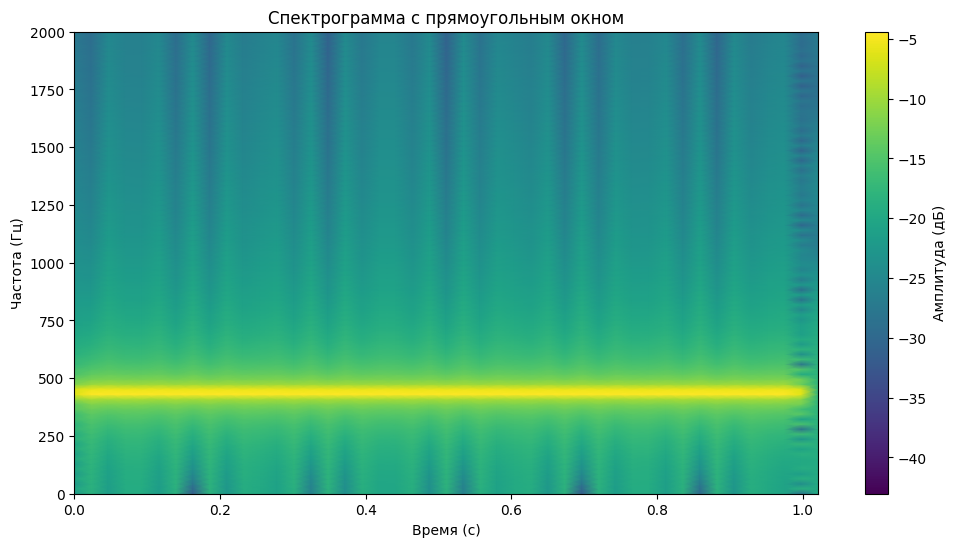

In [16]:

from scipy.signal import stft
import matplotlib.pyplot as plt

f, t_spec, Zxx = stft(sine_wave, fs=sr, window='boxcar', nperseg=1024, noverlap=512)

Zxx_db = 10 * np.log10(np.abs(Zxx) + 1e-10)

# вывод
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_spec, f, Zxx_db, shading='gouraud', cmap='viridis')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Спектрограмма с прямоугольным окном')
plt.colorbar(label='Амплитуда (дБ)')
plt.ylim(0, 2000)
plt.show()

### **2.3 Compute STFT with Hann window** [1 score]
- Repeat with `window='hann'`.
- Plot the spectrogram.

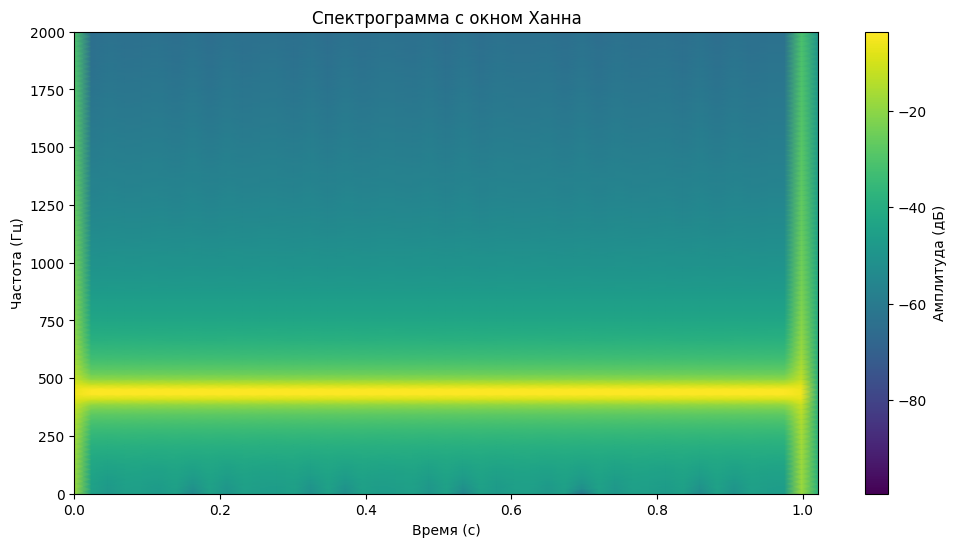

In [17]:
# Compute STFT with hann window
f_hann, t_spec_hann, Zxx_hann = stft(sine_wave, fs=sr, window='hann', nperseg=1024, noverlap=512)

Zxx_hann_db = 10 * np.log10(np.abs(Zxx_hann) + 1e-10)

# Plot spectrogram
plt.figure(figsize=(12, 6))
plt.pcolormesh(t_spec_hann, f_hann, Zxx_hann_db, shading='gouraud', cmap='viridis')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Спектрограмма с окном Ханна')
plt.colorbar(label='Амплитуда (дБ)')
plt.ylim(0, 2000)
plt.show()

### **2.4 Compare the two spectrograms** [1.5 score]
- **Question**: In the rectangular case, do you see energy at frequencies **other than 440 Hz**? [0.5 score]
- **Question**: Is the main lobe wider or narrower with Hann? [0.5 score]
- **Question**: Which window shows cleaner, more focused energy at 440 Hz? [0.5 score]

Answers to questions:

Вопрос: В случае прямоугольного окна видите ли вы энергию на частотах, отличных от 440 Гц? [0.5 балла]:
- Да. Видна энергия и на других частотах, много видно на 1 сек.

Вопрос: Главный лепесток шире или уже с окном Ханна? [0.5 балла]:
- С окном хана главный спектр шире

Вопрос: Какое окно показывает более чистую, сфокусированную энергию на 440 Гц? [0.5 балла]:
- Окно Хана, так как отсуствуют помехи на других частотах


### **2.5 Try a signal with two close frequencies** [2 score]
- Generate two sine waves: 440 Hz and 460 Hz.
- Repeat 2.2 and 2.3.
- **Question**: Can you distinguish the two tones with rectangular window? With Hann?


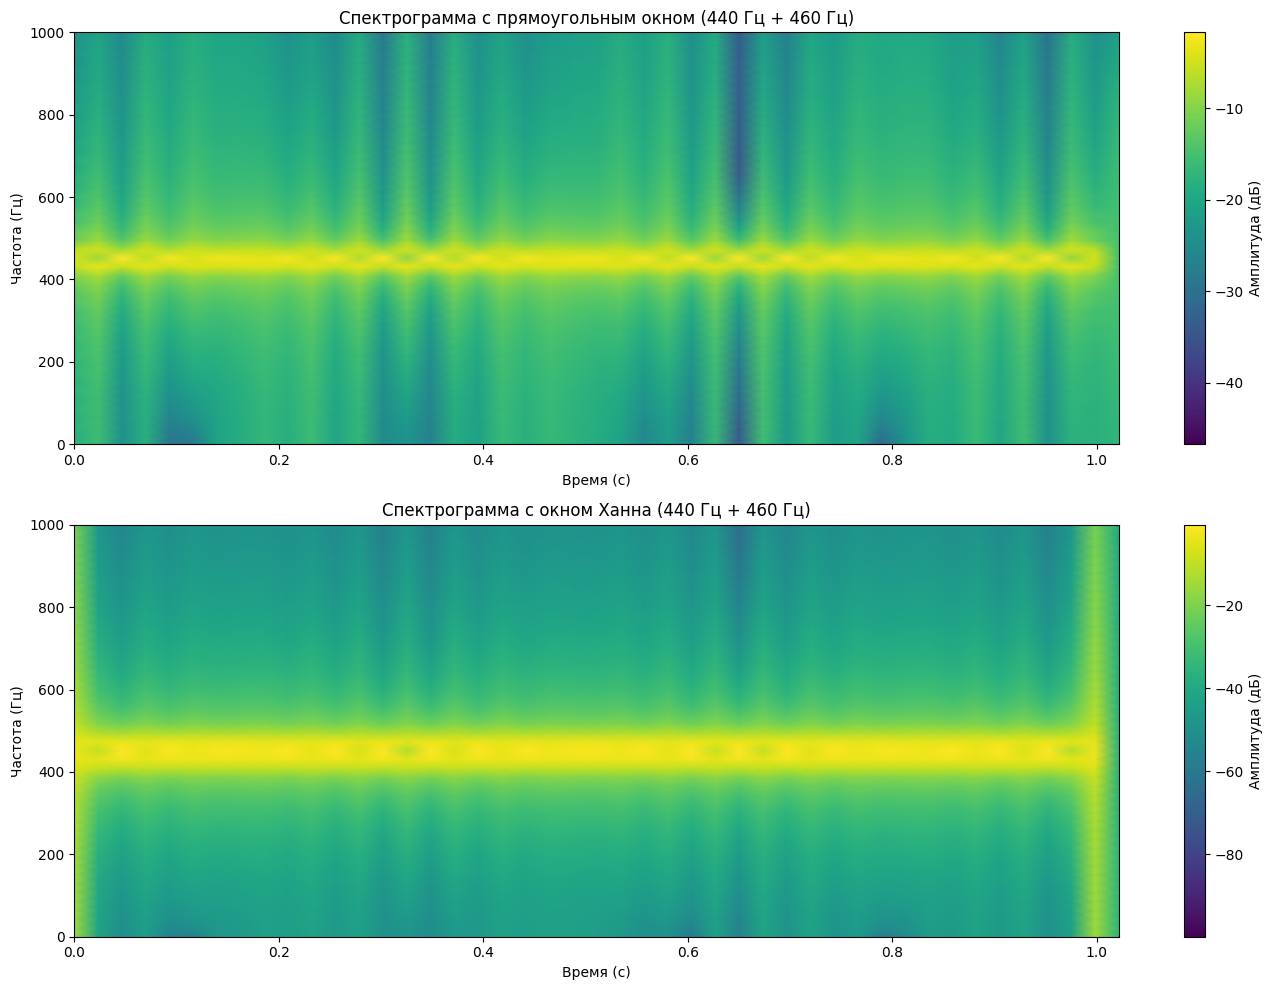

In [18]:
sr = 22050
duration = 1.0
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
f1, f2 = 440, 460

# Генерация двух синусоид
sine_wave_dual = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

# Прямоугольное окно
f_rect, t_rect, Zxx_rect = stft(sine_wave_dual, fs=sr, window='boxcar', nperseg=1024, noverlap=512)
Zxx_rect_db = 10 * np.log10(np.abs(Zxx_rect) + 1e-10)

# Окно Ханна
f_hann, t_hann, Zxx_hann = stft(sine_wave_dual, fs=sr, window='hann', nperseg=1024, noverlap=512)
Zxx_hann_db = 10 * np.log10(np.abs(Zxx_hann) + 1e-10)

# Построение спектрограмм
plt.figure(figsize=(14, 10))

# Прямоугольное окно
plt.subplot(2, 1, 1)
plt.pcolormesh(t_rect, f_rect, Zxx_rect_db, shading='gouraud', cmap='viridis')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Спектрограмма с прямоугольным окном (440 Гц + 460 Гц)')
plt.colorbar(label='Амплитуда (дБ)')
plt.ylim(0, 1000)

# Окно Ханна
plt.subplot(2, 1, 2)
plt.pcolormesh(t_hann, f_hann, Zxx_hann_db, shading='gouraud', cmap='viridis')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Спектрограмма с окном Ханна (440 Гц + 460 Гц)')
plt.colorbar(label='Амплитуда (дБ)')
plt.ylim(0, 1000)

plt.tight_layout()
plt.show()

Вопрос: Можете ли вы различить два тона с прямоугольным окном? С окном Ханна?

- На прямоугольном окне 2 тона слаборазличимы, возможно принять за артефакты. На окне Хана 2 тона выражены, но на некторых амплитудах происходит слияние в один широкий частотный спектр

### **2.6 Analyze a real instrument note** [1 score]
- Load a flute note (A5).
- Compute spectrograms with rectangular and Hann windows.
- **Question**: Does rectangular window create "smearing" or artificial frequencies? [0.5 score]
- **Question**: Which spectrogram better reflects the true harmonic structure? [0.5 score]

In [21]:
# Load flute note A5
row = df[(df['Instrument (in full)'] == "Flute") & (df['Pitch'] == 'A5')].iloc[0]
y_inst, sr_inst = librosa.load(row['Path'], sr=None)


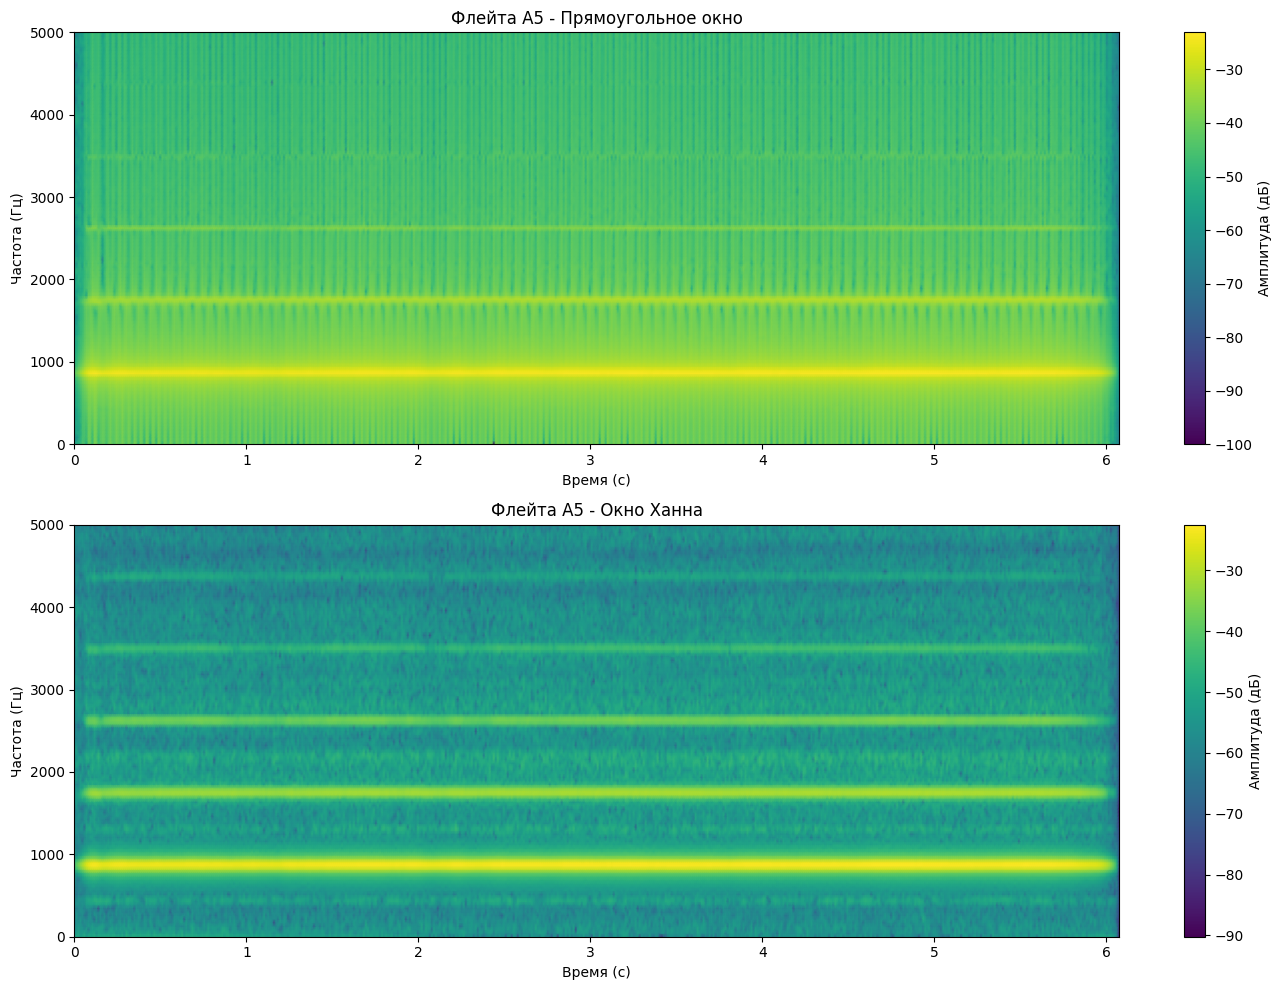

In [22]:
# Compute STFT with rectangular window
f_rect, t_rect, Zxx_rect = stft(y_inst, fs=sr_inst, window='boxcar', nperseg=1024, noverlap=512)
Zxx_rect_db = 10 * np.log10(np.abs(Zxx_rect) + 1e-10)

# Compute STFT with Hann window
f_hann, t_hann, Zxx_hann = stft(y_inst, fs=sr_inst, window='hann', nperseg=1024, noverlap=512)
Zxx_hann_db = 10 * np.log10(np.abs(Zxx_hann) + 1e-10)

# Plot spectrograms
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.pcolormesh(t_rect, f_rect, Zxx_rect_db, shading='gouraud', cmap='viridis')
plt.ylim(0, 5000)
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Флейта A5 - Прямоугольное окно')
plt.colorbar(label='Амплитуда (дБ)')

plt.subplot(2, 1, 2)
plt.pcolormesh(t_hann, f_hann, Zxx_hann_db, shading='gouraud', cmap='viridis')
plt.ylim(0, 5000)
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.title('Флейта A5 - Окно Ханна')
plt.colorbar(label='Амплитуда (дБ)')

plt.tight_layout()
plt.show()

**Answer**:

Вопрос: Создает ли прямоугольное окно "размытие" или искусственные частоты? [0.5 балла]
- Прямоугольное окно создает размытие и не все гармоники видно.

Вопрос: Какая спектрограмма лучше отражает истинную гармоническую структуру? [0.5 балла]
- Спектрограма окно Ханна лучше передают гармоническую структуру звука.

### **2.7 Conclusion** [3 score]
- Write 3–4 sentences explaining:
  - What is **spectral leakage**?
  - Why does rectangular window cause it?
  - Why is a smooth (bell-shaped) window better for audio analysis?

**Answer**:
Вопрос: Что такое спектральная утечка?
- Спектральная утечка — это явление, при котором энергия сигнала на одной частоте "просачивается" в соседние частоты спектра, создавая искусственные частотные компоненты.

Вопрос: Почему прямоугольное окно вызывает спектральную утечку?
- Прямоугольное окно вызывает сильную спектральную утечку из-за своих резких краев, которые во временной области действуют как ступенчатая функция, что в частотной области соответствует sinc-функции с высокими боковыми лепестками. Эти боковые лепестки распределяют энергию по множеству частотных бинов, маскируя слабые гармоники и искажая истинный спектральный состав.

Вопрос: Почему гладкое (колоколообразное) окно лучше для анализа аудио?
- Гладкое окно (например, Ханна или Хэмминга) плавно сводит сигнал к нулю на краях, устраняя разрывы и значительно подавляя боковые лепестки. Это концентрирует энергию более точно на истинных частотах, обеспечивая более чистое представление гармонической структуры. Для анализа аудио гладкие окна предпочтительнее, так как они лучше сохраняют подлинные тембральные характеристики и позволяют четче идентифицировать отдельные гармоники.

# **Task 3: Implement Your Own Mel-Spectrogram Transform** [5 score]

### **Goal**: Understand how Mel-scale warping works by implementing it manually.

### **3.1 Load an audio file** [0.5 score]
- Pick any `.wav` from the dataset.
- Load with `librosa.load(..., sr=22050)`.

In [23]:
# Load audio
sample = df.iloc[0]
y, sr = librosa.load(sample['Path'], sr=22050)

### **3.2 Compute STFT** [0.5 score]
- Use `librosa.stft` with `n_fft=2048`, `hop_length=512`, `window='hann'`.
- Compute power spectrogram: `S = np.abs(stft_result) ** 2`.

In [24]:
# Compute STFT
stft_result = librosa.stft(y, n_fft=2048, hop_length=512, window='hann')
S = np.abs(stft_result) ** 2


### **3.3 Create Mel filterbank manually** [2 score]
- Number of Mel bands: `n_mels = 128`.
- Frequency range: 0 to `sr/2`.
- Steps:
  1. Convert Hz to Mel: `mel = 2595 * np.log10(1 + f / 700)`
  2. Create `n_mels + 2` equally spaced points in Mel scale.
  3. Convert back to Hz.
  4. Build triangular filters (each filter overlaps with neighbors).
- Output: a matrix `mel_basis` of shape `(n_mels, n_fft//2 + 1)`.

> 📚 Reference: [Librosa mel filterbank docs](https://librosa.org/doc/main/generated/librosa.filters.mel.html)

In [26]:
def hz_to_mel(frequencies):
    """Convert Hz to Mel scale"""
    return 2595 * np.log10(1 + frequencies / 700)

def mel_to_hz(mels):
    """Convert Mel to Hz scale"""
    return 700 * (10**(mels / 2595) - 1)

def create_mel_filterbank(sr, n_fft, n_mels=128, fmin=0.0, fmax=None):
    """Create Mel filterbank manually"""

    if fmax is None:
        fmax = sr / 2

    # Frequency bins
    n_freqs = n_fft // 2 + 1
    linear_freqs = np.linspace(0, sr/2, n_freqs)

    # Mel points
    min_mel = hz_to_mel(fmin)
    max_mel = hz_to_mel(fmax)
    mel_points = np.linspace(min_mel, max_mel, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    # Create filterbank
    filterbank = np.zeros((n_mels, n_freqs))

    for m in range(n_mels):
        # Triangle vertices
        left = hz_points[m]
        center = hz_points[m + 1]
        right = hz_points[m + 2]

        # Rising part
        rising_mask = (linear_freqs >= left) & (linear_freqs <= center)
        filterbank[m, rising_mask] = (linear_freqs[rising_mask] - left) / (center - left)

        # Falling part
        falling_mask = (linear_freqs >= center) & (linear_freqs <= right)
        filterbank[m, falling_mask] = (right - linear_freqs[falling_mask]) / (right - center)

    return filterbank

# Create filterbank
n_fft = 2048
mel_basis_manual = create_mel_filterbank(sr, n_fft, n_mels=128)

### **3.4 Apply filterbank to power spectrogram** [0.5 score]
- Compute: `mel_spec_manual = np.dot(mel_basis, S)`

In [27]:
# Apply manual filterbank
mel_spec_manual = np.dot(mel_basis_manual, S)

### **3.5 Compute Mel-spectrogram using librosa** [0.5 score]
- Use `librosa.feature.melspectrogram(y=audio, sr=sr, n_fft=2048, hop_length=512, n_mels=128)`

In [28]:
# Librosa version
mel_spec_librosa = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)

### **3.6 Compare and validate** [1 score]
- Use `np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)`
- If not close, debug your filterbank.
- Plot both Mel-spectrograms side by side (in dB scale).
- **Question**: Are they visually identical?

Manual and librosa implementations match: False


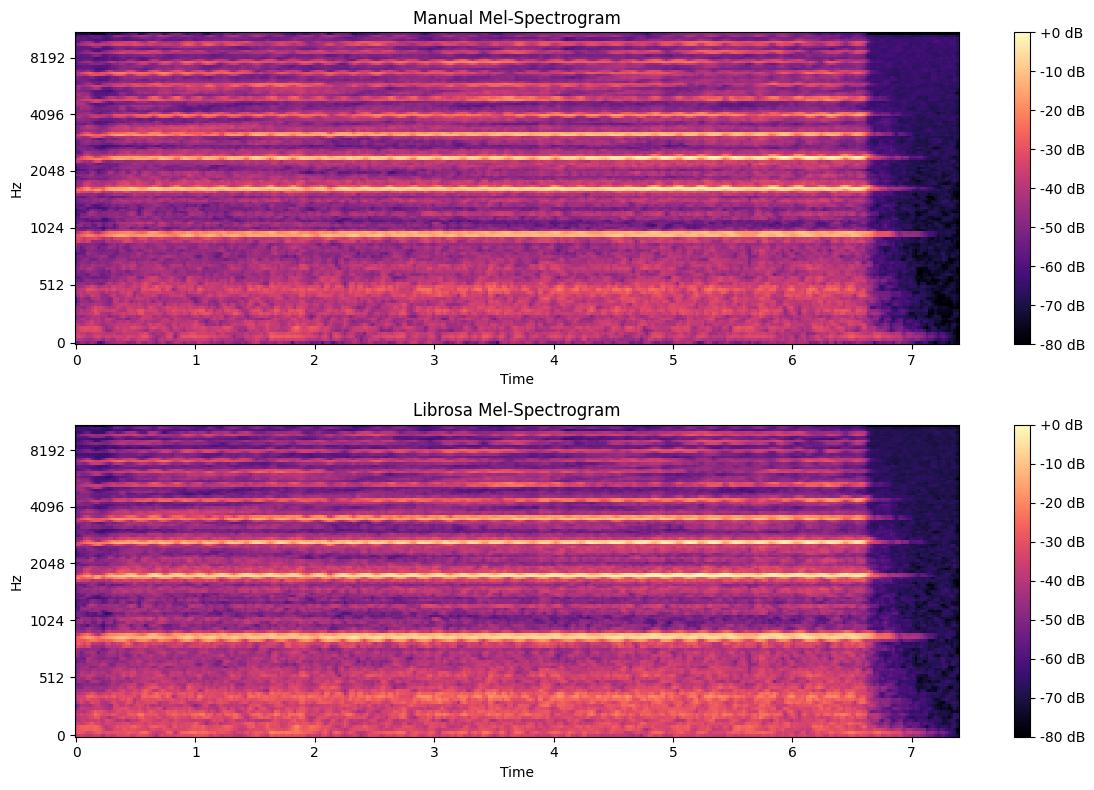

In [30]:
hop_length = 512

# Compare
are_close = np.allclose(mel_spec_manual, mel_spec_librosa, atol=1e-5)
print(f"Manual and librosa implementations match: {are_close}")

# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

img1 = librosa.display.specshow(
    librosa.power_to_db(mel_spec_manual, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax1
)
ax1.set_title('Manual Mel-Spectrogram')
plt.colorbar(img1, ax=ax1, format='%+2.0f dB')

img2 = librosa.display.specshow(
    librosa.power_to_db(mel_spec_librosa, ref=np.max),
    sr=sr, hop_length=hop_length, x_axis='time', y_axis='mel', ax=ax2
)
ax2.set_title('Librosa Mel-Spectrogram')
plt.colorbar(img2, ax=ax2, format='%+2.0f dB')

plt.tight_layout()
plt.show()

Вопрос: Они визуально идентичны?
- Да визуально идентичны с небольшим смещением частот в сторону увеличения и меньшей дельте между частотами на диаграмме Manual Mel-Spectrogram

### **3.7 Bonus: Try with torchaudio**
- Repeat using `torchaudio.transforms.MelSpectrogram`.
- Compare with your implementation.

In [ ]:
# !pip install torch torchaudio

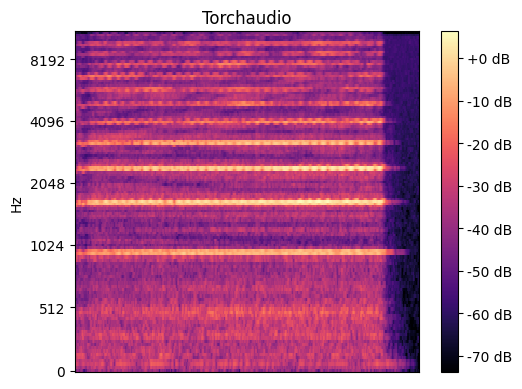

In [33]:
import torchaudio
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, n_fft=n_fft, hop_length=hop_length, n_mels=128
)
mel_spec_torch = mel_transform(torch.tensor(y)).numpy()

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 3)
librosa.display.specshow(librosa.power_to_db(mel_spec_torch), sr=sr, hop_length=hop_length, y_axis='mel')
plt.title('Torchaudio')
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

Результат максимально похожий на Manual Mel-Spectrogram